# AI Text Detector — XLM-RoBERTa Fine-Tuning

This notebook fine-tunes **XLM-RoBERTa** (a multilingual transformer) to classify text as either **AI-generated** or **human-written**.

The model is trained on a combined English and Arabic dataset to support bilingual detection.

### Environment Setup
Import standard libraries, resolve directories, and inspect the available data files within the environment.

In [1]:
# Standard imports provided by the Kaggle environment
import numpy as np   # numerical computing
import pandas as pd  # data manipulation
import os

# List all input files available in this Kaggle session
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/ramezfawzy/best-model-v2/best_model/config.json
/kaggle/input/datasets/ramezfawzy/best-model-v2/best_model/tokenizer.json
/kaggle/input/datasets/ramezfawzy/best-model-v2/best_model/training_state.pt
/kaggle/input/datasets/ramezfawzy/best-model-v2/best_model/tokenizer_config.json
/kaggle/input/datasets/ramezfawzy/best-model-v2/best_model/model.safetensors
/kaggle/input/datasets/ramezfawzy/dataset/final_english_ready_dataset.csv
/kaggle/input/datasets/ramezfawzy/dataset/final_arabic_dataset_ready.csv


## 1. Data Loading

Load the pre-processed English and Arabic datasets from Kaggle input.

In [2]:
import pandas as pd

df_en = pd.read_csv("/kaggle/input/datasets/ramezfawzy/dataset/final_english_ready_dataset.csv")
df_ar = pd.read_csv("/kaggle/input/datasets/ramezfawzy/dataset/final_arabic_dataset_ready.csv")

print(df_en.shape, df_en['label'].value_counts().to_dict())
print(df_ar.shape, df_ar['label'].value_counts().to_dict())

(475996, 3) {1: 248820, 0: 227176}
(512634, 3) {0: 256317, 1: 256317}


### Inspect column names

Check whether both datasets share the same schema before merging.

In [3]:
print(df_ar.columns.tolist())
print(df_en.columns.tolist())

['text', 'label', 'word_count']
['text', 'label', 'word_count']


## 2. Data Preparation
Ensure the schemas are aligned by isolating and keeping only the target necessary columns (`text` and `label`) specifically from the English dataset.

In [4]:
df_en = df_en[['text', 'label']]

### Balance the Arabic dataset

The Arabic dataset is imbalanced. We down-sample the human-written class to match the number of AI-generated samples.

In [5]:
human_ar = df_ar[df_ar['label'] == 0].sample(n=254228, random_state=42)
ai_ar    = df_ar[df_ar['label'] == 1]

df_ar = pd.concat([human_ar, ai_ar]).sample(frac=1, random_state=42).reset_index(drop=True)

print(df_ar['label'].value_counts())
print("Total:", len(df_ar))

label
1    256317
0    254228
Name: count, dtype: int64
Total: 510545


### Merge English + Arabic into one dataset

In [6]:
df = pd.concat([df_en, df_ar], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total   : {len(df):,}")
print(f"\nLabel dist:\n{df['label'].value_counts()}")

Total   : 986,541

Label dist:
label
1    505137
0    481404
Name: count, dtype: int64


## 3. Text Preprocessing & Aggregation
Assign distinctive language tags to both datasets ('en' and 'ar'), merge them sequentially into a single unified DataFrame, and randomize the sorting properly to prepare for training.

In [ ]:
df_en['lang'] = 'en'
df_ar['lang'] = 'ar'

df = pd.concat([df_en, df_ar], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total   : {len(df):,}")
print(f"\nLabel dist:\n{df['label'].value_counts()}")
print(f"\nLang dist:\n{df['lang'].value_counts()}")

Total   : 986,541

Label dist:
label
1    505137
0    481404
Name: count, dtype: int64

Lang dist:
lang
ar    510545
en    475996
Name: count, dtype: int64


### Detailed Dataset Inspection
Output a comprehensive profile of the merged dataset: trace its structural shape, calculate active duplicates / missing values, and print out random content excerpts of both true human-written and AI-generated rows.

In [9]:
print("=" * 50)
print("COMBINED DATASET — INSPECTION")
print("=" * 50)

print(f"\nShape      : {df.shape}")
print(f"Duplicates : {df.duplicated(subset=['text']).sum():,}")
print(f"Nulls      :\n{df.isnull().sum()}")

print("\n" + "=" * 50)
print("SAMPLES — HUMAN")
print("=" * 50)
for i, row in df[df['label'] == 0].sample(3, random_state=42).iterrows():
    print(f"\n[{i}] {row['text'][:200]}")
    print("-" * 40)

print("\n" + "=" * 50)
print("SAMPLES — AI")
print("=" * 50)
for i, row in df[df['label'] == 1].sample(3, random_state=42).iterrows():
    print(f"\n[{i}] {row['text'][:200]}")
    print("-" * 40)

print("\n" + "=" * 50)
print("LANGUAGE MIX CHECK")
print("=" * 50)
print(f"English rows : {len(df_en):,}")
print(f"Arabic rows  : {len(df_ar):,}")
print(f"Total        : {len(df):,}")

COMBINED DATASET — INSPECTION

Shape      : (986541, 4)
Duplicates : 0
Nulls      :
text               0
label              0
lang               0
word_count    475996
dtype: int64

SAMPLES — HUMAN

[815803] تسارع الإنتاج الصناعي الأمريكي خلال ديسمبر نما إنتاج المصانع الأمريكية بأكثر من المتوقع في ديسمبر، لكن اضطرابات لسلاسل الإمداد الناجمة عن استمرار ملازمة بعض العاملين للمنازل بسبب الانتشار الحاد للجائح
----------------------------------------

[862683] and successive waves of newcomers. Even city officials do not necessarily agree. In a 2006 article for The New York Times, Manny Fernandez described the disagreement: According to a Department of City
----------------------------------------

[400969] 648هـ المُوافق فيه 2 شُباط (فبراير) 1251م عند قرية العبَّاسة بين مدينتيّ بلبيس والصالحيَّة، فاشتبكا في معركةٍ انتصر فيها الأيُّوبيين بدايةً، ثُمَّ انقلبت الآية بسبب تخلِّي بعض المماليك من جيش الناصر ي
----------------------------------------

SAMPLES — AI

[307697] William S. Paley (1901

### Data Preview
Load and review the first 5 records of the completely merged dataset.

In [10]:
df.head()

,text,label,lang,word_count
0,on the orders of President Lyndon Johnson to p...,0,en,NaN
1,Abstract: We present a self-learning AI framew...,1,en,NaN
2,عام 1987. واستضافت كل من أستراليا ونيوزيلندا ك...,0,ar,146.0
3,والاعتقادُ بفضائلهم، كبيراً في المغرب من أيِّ ...,0,ar,211.0
4,"Mädchen Amick (born December 12, 1970) is an A...",1,en,NaN


### Exploratory Data Analysis (EDA)
Process empirical word counts across texts and generate plotted distributions:
1. Overall Label Frequency
2. Word Count clustered by Label
3. Word Count aggregated by Language

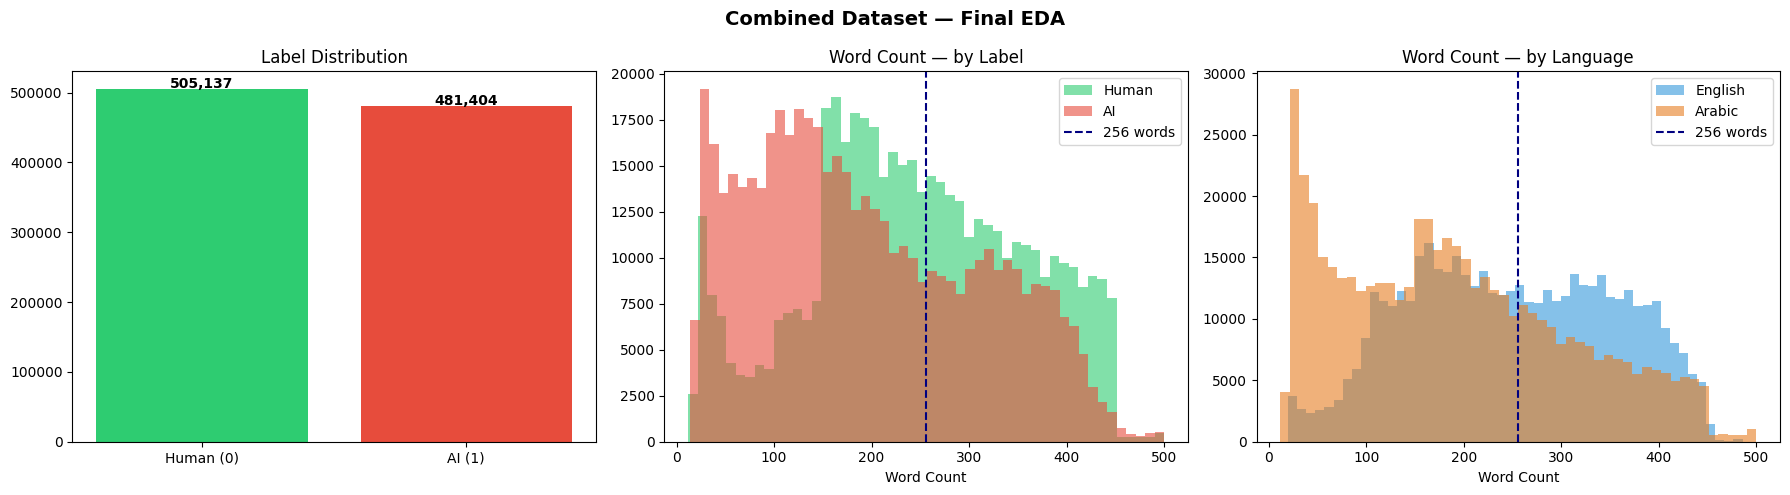

In [11]:
import matplotlib.pyplot as plt
import numpy as np

df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Combined Dataset — Final EDA", fontsize=14, fontweight="bold")

# 1. Label Distribution
counts = df['label'].value_counts()
axes[0].bar(["Human (0)", "AI (1)"], counts.values, color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Label Distribution")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontweight="bold")

# 2. Word Count Distribution — by label
for label, color, name in [(0, "#2ecc71", "Human"), (1, "#e74c3c", "AI")]:
    subset = df[df['label'] == label]['word_count']
    axes[1].hist(subset.clip(upper=500), bins=50, alpha=0.6, color=color, label=name)
axes[1].axvline(256, color="navy", linestyle="--", linewidth=1.5, label="256 words")
axes[1].set_title("Word Count — by Label")
axes[1].set_xlabel("Word Count")
axes[1].legend()

# 3. Word Count Distribution — by language
for lang, color, name in [("en", "#3498db", "English"), ("ar", "#e67e22", "Arabic")]:
    subset = df[df['lang'] == lang]['word_count']
    axes[2].hist(subset.clip(upper=500), bins=50, alpha=0.6, color=color, label=name)
axes[2].axvline(256, color="navy", linestyle="--", linewidth=1.5, label="256 words")
axes[2].set_title("Word Count — by Language")
axes[2].set_xlabel("Word Count")
axes[2].legend()

plt.tight_layout()
plt.savefig("combined_eda_final.png", dpi=150)
plt.show()

### Analyze Word Count Extremes
Determine and compute extreme word length occurrences. Display standard absolute maximum sizes and flag the general proportion of samples extending past standard threshold bounds (512 words) for English and Arabic.

In [12]:
print("=== English ===")
wc_en = df[df['lang'] == 'en']['word_count']
print(f"  Max    : {wc_en.max():,}")
print(f"  > 512  : {(wc_en > 512).sum():,} ({(wc_en > 512).mean()*100:.1f}%)")

print("\n=== Arabic ===")
wc_ar = df[df['lang'] == 'ar']['word_count']
print(f"  Max    : {wc_ar.max():,}")
print(f"  > 512  : {(wc_ar > 512).sum():,} ({(wc_ar > 512).mean()*100:.1f}%)")

=== English ===
  Max    : 486
  > 512  : 0 (0.0%)

=== Arabic ===
  Max    : 512
  > 512  : 0 (0.0%)


### Tokenizer setup and Dataset Class Definition
Load the primary `xlm-roberta-base` native tokenizer from HuggingFace and assemble a dedicated PyTorch `Dataset` wrapper (`AIDetectionDataset`) mapping texts and labels into padded/truncated token arrays.

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

class AIDetectionDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=512):
        self.texts     = df['text'].tolist()
        self.labels    = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Test
sample_dataset = AIDetectionDataset(df_train.head(5), tokenizer)
sample = sample_dataset[0]
print(f"input_ids shape     : {sample['input_ids'].shape}")
print(f"attention_mask shape: {sample['attention_mask'].shape}")
print(f"label               : {sample['label']}")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

input_ids shape     : torch.Size([512])
attention_mask shape: torch.Size([512])
label               : 0


### Initialize DataLoaders
Configure standard iterable DataLoader structures serving dynamically batched representations for defined Training, Validation, and Test collections to optimize graphical memory usage.

In [14]:
train_dataset = AIDetectionDataset(df_train, tokenizer)
val_dataset   = AIDetectionDataset(df_val,   tokenizer)
test_dataset  = AIDetectionDataset(df_test,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")
print(f"Test batches  : {len(test_loader):,}")

Train batches : 49,327
Val batches   : 6,166
Test batches  : 6,166


### Load Base Classification Model
Initialize a pre-trained `xlm-roberta-base` model strictly modified for sequence classification operations (2 labels), allocate it to the local operational device, and measure the trainable architecture parameters.

In [15]:
from transformers import AutoModelForSequenceClassification
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2,
    id2label={0: "human", 1: "ai"},
    label2id={"human": 0, "ai": 1}
)

model = model.to(device)

# تحقق
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Device: cuda


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params    : 278,045,186
Trainable params: 278,045,186


### Configure Multi-GPU Utilization
Check the current environment constraints for distributed hardware GPUs. Bind and implement native `DataParallel` extensions across the model wrapper if computational clusters are available.

In [16]:
# Multi-GPU
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs ")
    model = torch.nn.DataParallel(model)

model = model.to(device)
print(f"Device: {device}")
print(f"GPUs available: {torch.cuda.device_count()}")

Using 2 GPUs 
Device: cuda
GPUs available: 2


### Set Hyperparameters and Optimizer Scheduling
Calibrate operational hyperparameters governing epochs, base learning rates, warmups, and computational backward step accumulations. Implement the underlying `AdamW` optimizer matrix with linear scaling scheduler.

In [17]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

EPOCHS             = 1
TOTAL_EPOCHS       = 3
LR                 = 2e-5
ACCUMULATION_STEPS = 2
scaler             = GradScaler()

WARMUP_STEPS = int(0.1 * len(train_loader) * TOTAL_EPOCHS)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=len(train_loader) * TOTAL_EPOCHS
)

print(f"Epochs (this session) : {EPOCHS}")
print(f"Total Epochs          : {TOTAL_EPOCHS}")
print(f"LR                    : {LR}")
print(f"Total steps           : {len(train_loader) * TOTAL_EPOCHS:,}")
print(f"Warmup steps          : {WARMUP_STEPS:,}")

Epochs (this session) : 1
Total Epochs          : 3
LR                    : 2e-05
Total steps           : 147,981
Warmup steps          : 14,798


/tmp/ipykernel_57/1477825618.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler             = GradScaler()


## 4. Model Setup & Training
Formulate and encapsulate the distinct algorithm defining a standalone training epoch, taking advantage of local Automatic Mixed Precision (AMP) logic and GradScaler structures to accelerate model fine-tuning processes natively.

In [18]:
from tqdm.auto import tqdm

def train_epoch(model, loader, optimizer, scheduler, device, scaler):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc="Training")):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        with torch.amp.autocast('cuda'):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss    = outputs.loss
            if isinstance(loss, torch.Tensor) and loss.dim() > 0:
                loss = loss.mean()
            loss = loss / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        total_loss += loss.item() * ACCUMULATION_STEPS
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    return {
        "loss": total_loss / len(loader),
        "acc":  accuracy_score(all_labels, all_preds),
        "f1":   f1_score(all_labels, all_preds, average="binary")
    }

### Define Evaluation Execution Loop
Implement an active evaluation mapping method. Runs inference over a targeted loader subset continuously calculating resulting categorical losses, absolute accuracy metrics, and exact F1 scores without accumulating gradient memories.

In [19]:
def eval_epoch(model, loader, device, desc="Evaluating"):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)

            with torch.amp.autocast('cuda'):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss    = outputs.loss
                if isinstance(loss, torch.Tensor) and loss.dim() > 0:
                    loss = loss.mean()

            total_loss += loss.item()
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    return {
        "loss": total_loss / len(loader),
        "acc":  accuracy_score(all_labels, all_preds),
        "f1":   f1_score(all_labels, all_preds, average="binary")
    }

### Process Checkpointing and Resume Behaviors
Inspect local outputs systematically identifying saved model artifacts checkpoint components. Programmatically restore state and continue metric monitoring natively or provision a strictly clean start template dict.

In [20]:
import os
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW

RESUME_PATH = "/kaggle/input/datasets/ramezfawzy/best-model-v2/best_model"
RESUME = os.path.exists(RESUME_PATH + "/training_state.pt")

start_epoch = 0
best_val_f1 = 0

if RESUME:
    model = torch.nn.DataParallel(
        AutoModelForSequenceClassification.from_pretrained(
            RESUME_PATH, local_files_only=True).to(device)
    )
    state = torch.load(RESUME_PATH + "/training_state.pt")
    start_epoch = state['epoch'] + 1
    best_val_f1 = state['best_val_f1']
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    scaler = torch.amp.GradScaler('cuda')
    optimizer.zero_grad()

    if 'history' in state:
        history = state['history']
        print(f" History loaded — {len(history['train_loss'])} epochs so far")
    else:
        history = {"train_loss": [], "train_acc": [], "train_f1": [],
                   "val_loss":   [], "val_acc":   [], "val_f1":   []}
        print(" No history in checkpoint — starting fresh")

    print(f" Resumed — epoch {start_epoch} | Best F1: {best_val_f1:.4f}")
else:
    history = {"train_loss": [], "train_acc": [], "train_f1": [],
               "val_loss":   [], "val_acc":   [], "val_f1":   []}
    print(" Starting from scratch — Epoch 1")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

 No history in checkpoint — starting fresh
 Resumed — epoch 1 | Best F1: 0.9791


### Inject Initial Historical Base Metrics
Mechanically transfer recorded validation milestones from unlogged prior training intervals back securely into active memory tracking dictionary logs enabling clean visualization continuations.

In [21]:
history["train_loss"].append(0.0387)
history["train_acc"].append(0.9863)
history["train_f1"].append(0.9866)
history["val_loss"].append(0.0810)
history["val_acc"].append(0.9742)
history["val_f1"].append(0.9753)
print(f" Epoch 2 added — history now has {len(history['train_loss'])} epochs")

 Epoch 2 added — history now has 1 epochs


### Training Session Pipeline
Initialize the definitive looping pipeline controlling sequential calls orchestrating complete `train` and sequential `validation` updates. Log active metrics actively and compile a compressed archive snapshot representing only the single best functional model parameters to persistent files.

In [22]:
from sklearn.metrics import accuracy_score, f1_score
import shutil

for epoch in range(start_epoch, start_epoch + EPOCHS):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{TOTAL_EPOCHS}")
    print(f"{'='*50}")

    train_metrics = train_epoch(model, train_loader, optimizer, scheduler, device, scaler)
    val_metrics   = eval_epoch(model, val_loader, device, desc="Validating")

    print(f"\nTrain — Loss: {train_metrics['loss']:.4f} | Acc: {train_metrics['acc']:.4f} | F1: {train_metrics['f1']:.4f}")
    print(f"Val   — Loss: {val_metrics['loss']:.4f} | Acc: {val_metrics['acc']:.4f} | F1: {val_metrics['f1']:.4f}")

    history["train_loss"].append(train_metrics["loss"])
    history["train_acc"].append(train_metrics["acc"])
    history["train_f1"].append(train_metrics["f1"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["acc"])
    history["val_f1"].append(val_metrics["f1"])

    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        model.module.save_pretrained("best_model_version_2")
        tokenizer.save_pretrained("best_model_version_2")
        torch.save({
            'epoch': epoch,
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_f1': best_val_f1,
            'history': history,
        }, "best_model_version_2/training_state.pt")
        print(f"   Best model saved (F1: {best_val_f1:.4f})")
        shutil.make_archive("best_model_version_2", 'zip', "best_model_version_2")
        print(" Zip ready in Output")
    else:
        print(f"   No improvement (Best F1 still: {best_val_f1:.4f})")


Epoch 2/3


Training:   0%|          | 0/49327 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/tmp/ipykernel_57/3749411718.py:26: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Validating:   0%|          | 0/6166 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



Train — Loss: 0.0303 | Acc: 0.9894 | F1: 0.9896
Val   — Loss: 0.0922 | Acc: 0.9686 | F1: 0.9702
   No improvement (Best F1 still: 0.9791)


## 5. Training Curves
Formulate linear charts assessing aggregate recorded metric values graphing Training against Validation variables to identify trends relating directly to overfitting anomalies or learning inefficiencies mapping out Loss and explicit Accuracy thresholds comprehensively.

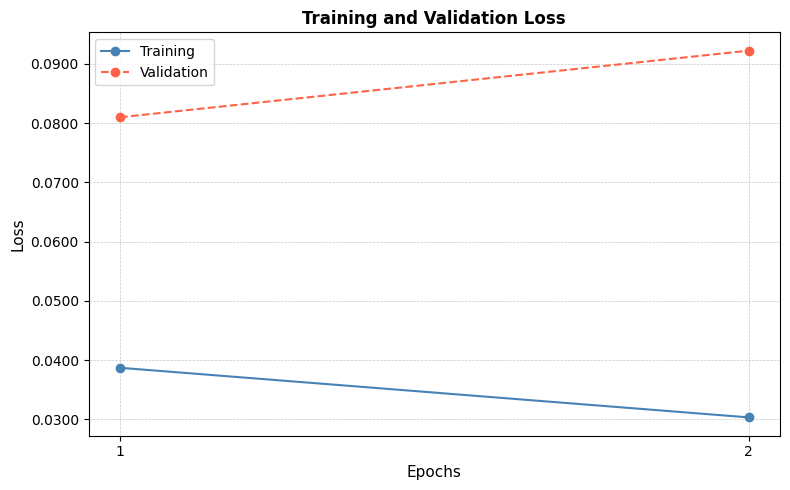

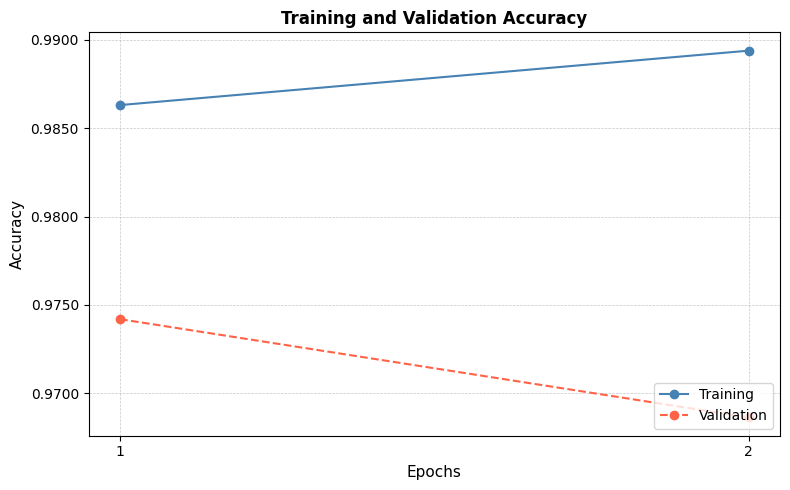

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

epochs = range(1, len(history["train_loss"]) + 1)

# Loss Curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, history["train_loss"], color="steelblue", linewidth=1.5, marker="o", label="Training")
ax.plot(epochs, history["val_loss"],   color="tomato",    linewidth=1.5, marker="o", linestyle="--", label="Validation")
ax.set_title("Training and Validation Loss", fontsize=12, fontweight="bold")
ax.set_xlabel("Epochs", fontsize=11)
ax.set_ylabel("Loss", fontsize=11)
ax.set_xticks(list(epochs))
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# Accuracy Curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, history["train_acc"], color="steelblue", linewidth=1.5, marker="o", label="Training")
ax.plot(epochs, history["val_acc"],   color="tomato",    linewidth=1.5, marker="o", linestyle="--", label="Validation")
ax.set_title("Training and Validation Accuracy", fontsize=12, fontweight="bold")
ax.set_xlabel("Epochs", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_xticks(list(epochs))
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))
plt.tight_layout()
plt.savefig("accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Model Evaluation
Reload operational pointers extracting only optimally saved model architecture artifacts stored explicitly in check-points to evaluate functional scoring against designated held-out Test subsets strictly separated.

In [24]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from transformers import AutoModelForSequenceClassification
import torch
from transformers import AutoTokenizer
from tqdm.auto import tqdm

model = AutoModelForSequenceClassification.from_pretrained("/kaggle/input/datasets/ramezfawzy/best-model-v2/best_model")
tokenizer = AutoTokenizer.from_pretrained("/kaggle/input/datasets/ramezfawzy/best-model-v2/best_model")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = model.to(device)
if torch.cuda.device_count() > 1:
    model = torch.nn.DataParallel(model)
model = model.to(device)

test_dataset  = AIDetectionDataset(df_test,  tokenizer)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

test_metrics = eval_epoch(model, test_loader, device, desc="Testing")
print(f"Test — Loss: {test_metrics['loss']:.4f} | Acc: {test_metrics['acc']:.4f} | F1: {test_metrics['f1']:.4f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Device: cuda


Testing:   0%|          | 0/6166 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Test — Loss: 0.0594 | Acc: 0.9781 | F1: 0.9790


### Produce Segmented Predictive Confusion Metrics
Extrapolate unmitigated predictions assessing granular true-vs-false categorical interactions mathematically summarizing precise Precision, Recall, and Accuracy scores strictly mapping variations mapped simultaneously to overall datasets, explicitly isolated isolated English components, and localized Arabic portions.

Total: 98,655 | EN: 47,583 | AR: 51,072


/tmp/ipykernel_57/1125725294.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_57/1125725294.py:84: UserWarning: Glyph 127468 (\N{REGIONAL INDICATOR SYMBOL LETTER G}) missing from font(s) DejaVu Sans.
  plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_57/1125725294.py:84: UserWarning: Glyph 127463 (\N{REGIONAL INDICATOR SYMBOL LETTER B}) missing from font(s) DejaVu Sans.
  plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_57/1125725294.py:84: UserWarning: Glyph 127480 (\N{REGIONAL INDICATOR SYMBOL LETTER S}) missing from font(s) DejaVu Sans.
  plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_57/1125725294.py:84: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
/t

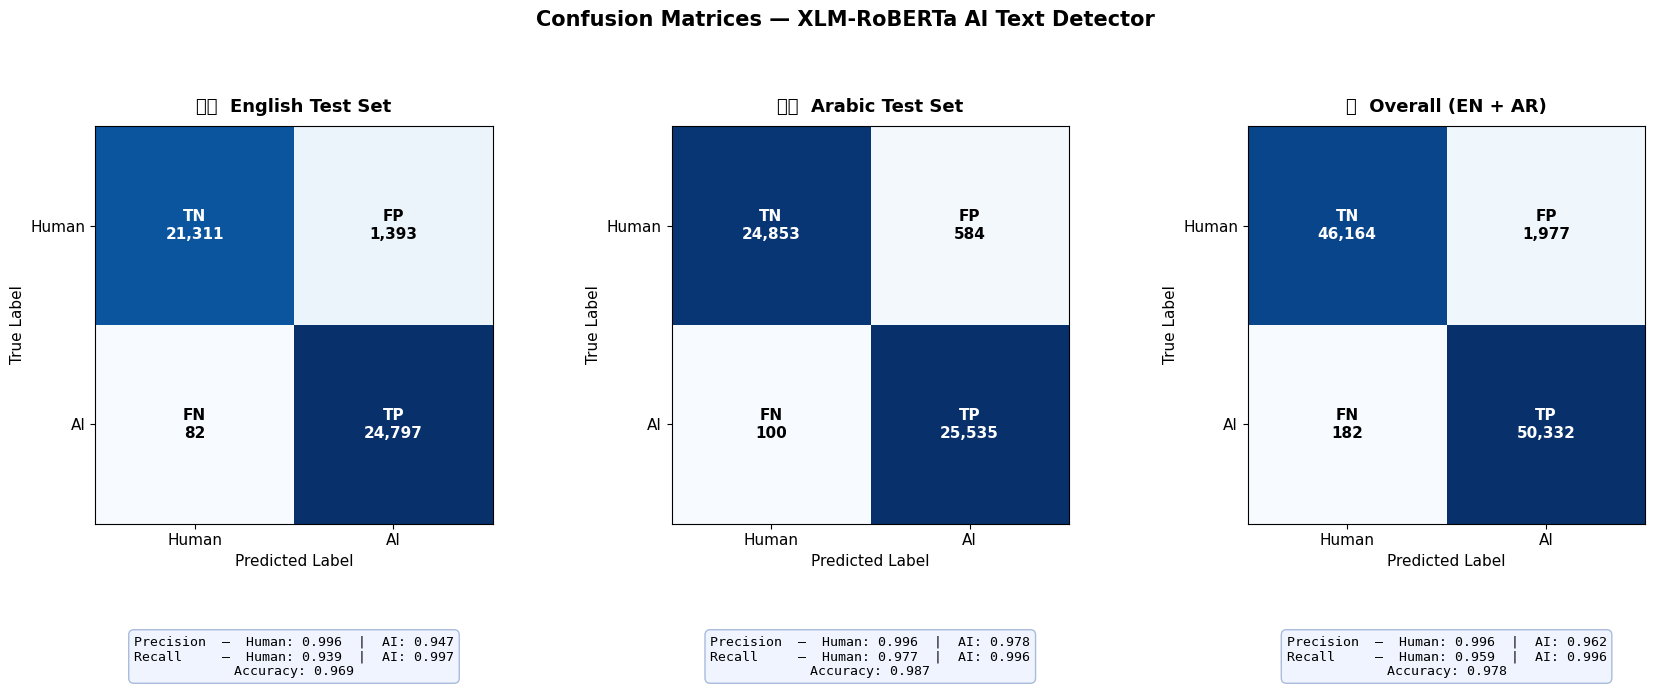



  [English]  Samples: 47,583  |  Accuracy: 0.9690
    Human  — P: 0.9962  R: 0.9386  F1: 0.9666
    AI     — P: 0.9468  R: 0.9967  F1: 0.9711

  [Arabic]  Samples: 51,072  |  Accuracy: 0.9866
    Human  — P: 0.9960  R: 0.9770  F1: 0.9864
    AI     — P: 0.9776  R: 0.9961  F1: 0.9868

  [Overall]  Samples: 98,655  |  Accuracy: 0.9781
    Human  — P: 0.9961  R: 0.9589  F1: 0.9772
    AI     — P: 0.9622  R: 0.9964  F1: 0.9790


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import torch
from tqdm.auto import tqdm

model.eval()

# Lang mapping
df_with_lang = df.copy()
test_langs = df_with_lang.loc[df_test.index, "lang"].reset_index(drop=True)

all_preds, all_labels, all_langs = [], [], []

with torch.no_grad():
    for i, batch in enumerate(tqdm(test_loader, desc="Collecting predictions")):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = outputs.logits.argmax(dim=-1).cpu().numpy()

        start = i * test_loader.batch_size
        end   = start + len(preds)

        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_langs.extend(test_langs.iloc[start:end].tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_langs  = np.array(all_langs)

print(f"Total: {len(all_preds):,} | EN: {(all_langs=='en').sum():,} | AR: {(all_langs=='ar').sum():,}")

# ---- Plot ----
def plot_cm(ax, cm, title, classes=["Human", "AI"]):
    ax.imshow(cm, interpolation="nearest", cmap="Blues")
    tp = cm[1,1]; fn = cm[1,0]; fp = cm[0,1]; tn = cm[0,0]
    precision_ai    = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_ai       = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_human = tn / (tn + fn) if (tn + fn) > 0 else 0
    recall_human    = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy        = (tp + tn) / cm.sum()

    thresh = cm.max() / 2.0
    labels_text = [[f"TN\n{tn:,}", f"FP\n{fp:,}"], [f"FN\n{fn:,}", f"TP\n{tp:,}"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, labels_text[i][j], ha="center", va="center",
                    fontsize=11, color="white" if cm[i,j] > thresh else "black", fontweight="bold")

    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.text(0.5, -0.28,
        f"Precision  —  Human: {precision_human:.3f}  |  AI: {precision_ai:.3f}\n"
        f"Recall     —  Human: {recall_human:.3f}  |  AI: {recall_ai:.3f}\n"
        f"Accuracy: {accuracy:.3f}",
        transform=ax.transAxes, ha="center", va="top", fontsize=9.5, family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", fc="#f0f4ff", ec="#aabbdd", lw=1))

mask_en = all_langs == "en"
mask_ar = all_langs == "ar"

cm_en      = confusion_matrix(all_labels[mask_en], all_preds[mask_en])
cm_ar      = confusion_matrix(all_labels[mask_ar], all_preds[mask_ar])
cm_overall = confusion_matrix(all_labels, all_preds)

fig = plt.figure(figsize=(20, 6))
fig.suptitle("Confusion Matrices — XLM-RoBERTa AI Text Detector", fontsize=15, fontweight="bold", y=1.02)
gs = gridspec.GridSpec(1, 3, wspace=0.45)

plot_cm(fig.add_subplot(gs[0]), cm_en,      "🇬🇧  English Test Set")
plot_cm(fig.add_subplot(gs[1]), cm_ar,      "🇸🇦  Arabic Test Set")
plot_cm(fig.add_subplot(gs[2]), cm_overall, "🌍  Overall (EN + AR)")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# Console summary
print("\n" + "="*55)
for tag, mask in [("English", mask_en), ("Arabic", mask_ar), ("Overall", np.ones(len(all_labels), dtype=bool))]:
    y_true = all_labels[mask]; y_pred = all_preds[mask]
    print(f"\n  [{tag}]  Samples: {len(y_true):,}  |  Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    for cls, lbl in [("Human", 0), ("AI", 1)]:
        p = precision_score(y_true, y_pred, pos_label=lbl, zero_division=0)
        r = recall_score(y_true, y_pred, pos_label=lbl, zero_division=0)
        f = f1_score(y_true, y_pred, pos_label=lbl, zero_division=0)
        print(f"    {cls:6s} — P: {p:.4f}  R: {r:.4f}  F1: {f:.4f}")

### Process Extended ROC Distributions
Analyze distinct probability ranges assessing operational True Positive vs False Positive fluctuations outputting explicit graph configurations plotting specific Receiver Operating Characteristic Area-Under-The-Curve (ROC-AUC) variations per corresponding languages securely mapped.

ROC — collecting probs:   0%|          | 0/6166 [00:00<?, ?it/s]

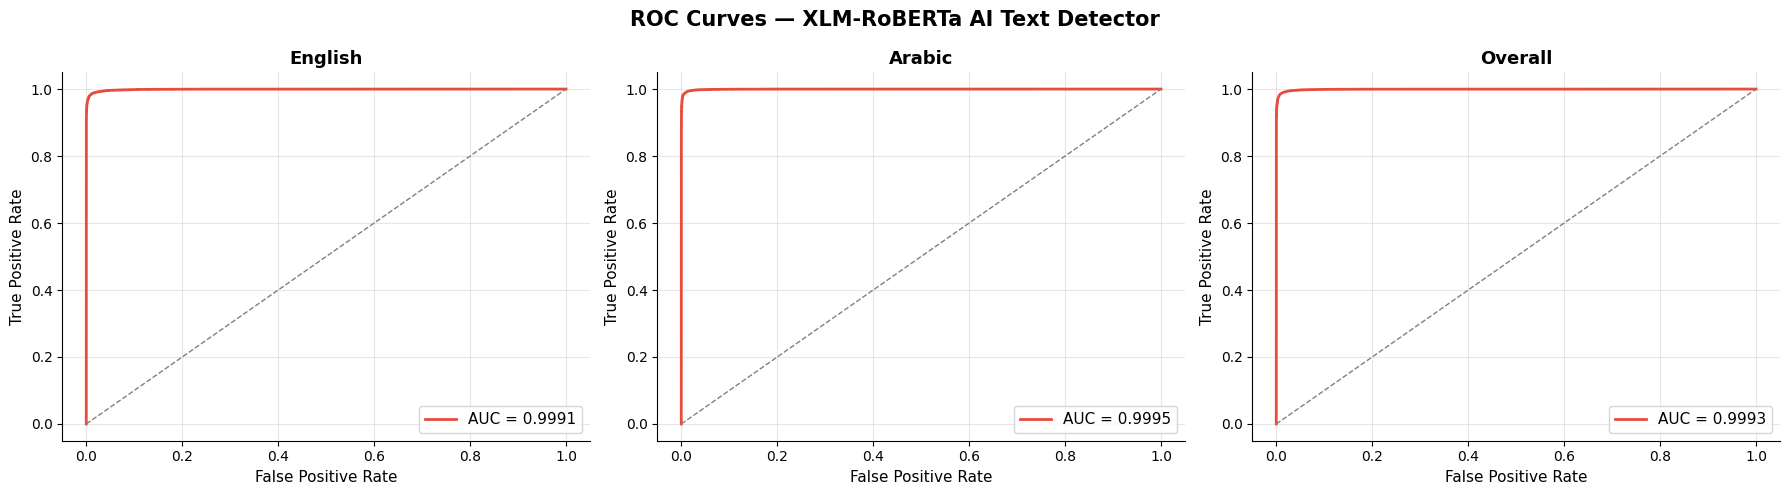

In [26]:
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

# Collect probabilities
model.eval()
all_probs  = []
all_labels_roc = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="ROC — collecting probs"):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = F.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy()

        all_probs.extend(probs)
        all_labels_roc.extend(labels.cpu().numpy())

all_probs      = np.array(all_probs)
all_labels_roc = np.array(all_labels_roc)

# Plot
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ROC Curves — XLM-RoBERTa AI Text Detector", fontsize=15, fontweight="bold")

for i, (tag, mask) in enumerate([
    ("English", all_langs == "en"),
    ("Arabic",  all_langs == "ar"),
    ("Overall", np.ones(len(all_labels_roc), dtype=bool))
]):
    fpr, tpr, _ = roc_curve(all_labels_roc[mask], all_probs[mask])
    roc_auc     = auc(fpr, tpr)

    ax[i].plot(fpr, tpr, color="#e74c3c", linewidth=2,
               label=f"AUC = {roc_auc:.4f}")
    ax[i].plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
    ax[i].set_title(tag, fontsize=13, fontweight="bold")
    ax[i].set_xlabel("False Positive Rate", fontsize=11)
    ax[i].set_ylabel("True Positive Rate", fontsize=11)
    ax[i].legend(fontsize=11)
    ax[i].grid(alpha=0.3)
    ax[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Operational Inference Demos
Re-acquire and actively inject absolute fully-trained configuration components natively to instantiate isolated programmatic verifications mimicking direct real-world text classifications manually over unseen singular records fundamentally simulating typical usage outputs definitively.

In [27]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("/kaggle/input/datasets/ramezfawzy/best-model-v2/best_model")
tokenizer = AutoTokenizer.from_pretrained("/kaggle/input/datasets/ramezfawzy/best-model-v2/best_model")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

### Declare Static Descriptive Wikipedia Passage
Construct a standardized English test subject manually capturing typical informational non-fictional characteristics actively representative of fundamental unedited organic human textual signatures comprehensively modeled natively.

In [28]:
text_from_wiki="Many countries were economically prosperous and spreading globalization. High-income countries experienced steady growth during the Great Moderation (1980s—2000s). Using a mobile phone in a public place was typical conspicuous consumption. In contrast, the GDP of former Soviet Union states declined as a result of neoliberal restructuring. International trade increased with the establishment of the European Union (EU) in 1993, North American Free Trade Agreement (NAFTA) in 1994, and World Trade Organization (WTO) in 1995. The Asia-Pacific economies of the Four Asian Tigers, ASEAN, Australia and Japan were hampered by the 1997 Asian financial crisis and early 1990s recession."

### Declare Synthesized Prompted Generation Passage
Map an independent paragraph mechanically generated simulating language-agent syntactical behaviors effectively highlighting the strict thematic structures associated inherently with LLM artificial production matrices targeting the specific model verification checks actively.

In [29]:
text_from_AI="The story of the RMS Titanic is one of the most famous maritime tragedies in history. Built by the Harland and Wolff in Belfast, the Titanic was designed to be the largest and most luxurious passenger ship of its time. It was operated by the White Star Line and was often described as “unsinkable” due to its advanced safety features and engineering."

### Execute Predictor Framework: Organic Extract
Sequence targeted individual string components into native localized models rendering categorical probabilities verifying and extracting final absolute classification tags mapping exactly to organic Human generations structurally explicitly output.

In [30]:
import torch.nn.functional as F

inputs = tokenizer(text_from_wiki, return_tensors="pt")
outputs = model(**inputs)
prediction = outputs.logits.argmax(dim=-1).item()

probs = F.softmax(outputs.logits, dim=-1)
confidence = probs.max().item()
prediction = probs.argmax(dim=-1).item()

label = "AI" if prediction == 1 else "Human"
print(f"Prediction: {label} ({confidence:.2%})")

Prediction: Human (94.85%)


### Execute Predictor Framework: Synthesized Format
Transmit explicitly non-human syntactical samples testing dynamic operational output frameworks generating quantitative probability inferences definitively flagging explicit AI boundaries objectively.

In [31]:
import torch.nn.functional as F

inputs = tokenizer(text_from_AI, return_tensors="pt")
outputs = model(**inputs)
prediction = outputs.logits.argmax(dim=-1).item()

probs = F.softmax(outputs.logits, dim=-1)
confidence = probs.max().item()
prediction = probs.argmax(dim=-1).item()

label = "AI" if prediction == 1 else "Human"
print(f"Prediction: {label} ({confidence:.2%})")

Prediction: AI (99.83%)


## 8. Comprehensive Training Epoch Synthesizing
Gather discrete variable metrics aggregating total progression indicators globally and statically rendering comprehensive terminal summaries evaluating aggregate trajectory graphs mapped directly effectively to absolute final presentation documentations.

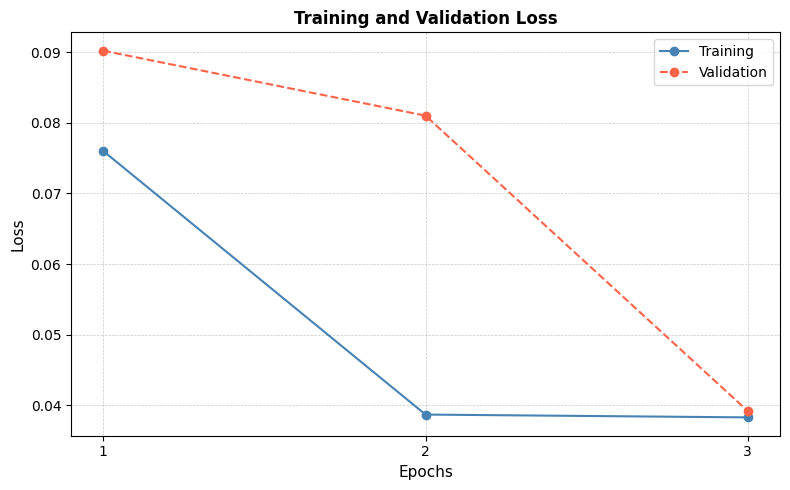

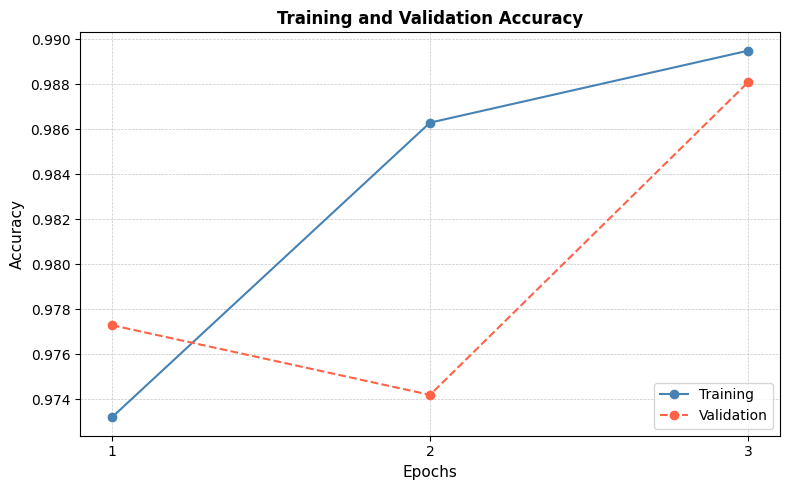

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

history = {
    "train_loss": [0.0760, 0.0387, 0.0383],
    "train_acc":  [0.9732, 0.9863, 0.9895],
    "val_loss":   [0.0902, 0.0810, 0.0392],
    "val_acc":    [0.9773, 0.9742, 0.9881],
}

epochs = range(1, 4)

# Loss Curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, history["train_loss"], color="steelblue", linewidth=1.5, marker="o", label="Training")
ax.plot(epochs, history["val_loss"],   color="tomato",    linewidth=1.5, marker="o", linestyle="--", label="Validation")
ax.set_title("Training and Validation Loss", fontsize=12, fontweight="bold")
ax.set_xlabel("Epochs", fontsize=11)
ax.set_ylabel("Loss", fontsize=11)
ax.set_xticks([1, 2, 3])
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# Accuracy Curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, history["train_acc"], color="steelblue", linewidth=1.5, marker="o", label="Training")
ax.plot(epochs, history["val_acc"],   color="tomato",    linewidth=1.5, marker="o", linestyle="--", label="Validation")
ax.set_title("Training and Validation Accuracy", fontsize=12, fontweight="bold")
ax.set_xlabel("Epochs", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_xticks([1, 2, 3])
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig("accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()